# Medical Aid Customer Review Analysis
## Pipelines and Text Data, LDA Topic Modelling & Supervised Sentiment Classification

**Student:** Liam Johnie
**Student Number:** ST10536072
**Module:** PDAN8411, POE Part 3

This notebook analyses customer review text for a South African medical aid scheme using two complementary methods: Latent Dirichlet Allocation (LDA) for unsupervised topic modelling and a supervised TF-IDF + classifier pipeline for sentiment analysis.

## 1. Introduction and Client Problem

A South African medical aid scheme faces rising negative public reviews on platforms such as Hello Peter. The scheme needs answers to two questions: what broad areas drive customer concern, and what is the overall sentiment of the customer base?

This notebook delivers both. LDA topic modelling surfaces recurring concern themes from review text, while a supervised TF-IDF plus classifier pipeline classifies customer sentiment. Three success criteria guide the work: interpretable concern topics that carry business-meaningful labels; a sentiment model that prioritises recall on negative reviews, because a missed dissatisfied customer is the costlier error; and a cross-analysis linking concern topics to negative sentiment so the client can prioritise remedial action. No public Hello Peter dataset for a single medical aid scheme is available, so a public insurance customer-review corpus is used as a proxy, justified in Section 2.

## 2. Dataset Source and Suitability

**Source.** The dataset is *Reviews about Insurance companies* published on Kaggle (Rihab, 2021). A medical aid is a health-insurance product, and these reviews cover the same service touchpoints targeted by the brief's "areas of concern": sign-up and onboarding, agent and call-centre interactions, claims processing, and coverage decisions. The proxy is therefore appropriate.

**Suitability for LDA.** The Review Text column contains natural-language free text with a mean length of 184 characters, one review per row, across 44,934 rows. This volume is ample for stable topic discovery with `LatentDirichletAllocation` (scikit-learn developers, 2024).

**Suitability for sentiment.** No rating, score, or label column exists (confirmed in Section 5.4), so supervised ground-truth labels are unavailable. Sentiment labels are derived using VADER, a lexicon-and-rule model designed for short, informal review and social-media text (Hutto and Gilbert, 2014), then used to train a supervised TF-IDF plus classifier pipeline. A manual sample of VADER labels is validated during preprocessing. The limitation is plain: sentiment evaluation metrics measure agreement with lexicon-derived labels rather than human ground truth, mitigated by manual validation and by prioritising model interpretability.

**Data quality (from the audit).** The dataset has 44,934 rows and 4 columns with zero missing values and no exact duplicate rows. The raw audit flags 234 duplicate review texts (approximately 0.5%). After whitespace normalisation an additional 13 become exact duplicates, so 247 are removed before modelling to avoid biasing topic distributions and sentiment class proportions. No empty or very short (< 20 character) reviews were found. `Unnamed: 0` is a leftover index (dropped). `Customer Name` is personal data (dropped for the ethics requirement). `Customer Location` contains mostly two-letter country codes, predominantly US (retained only for descriptive EDA, not modelling).

**Pitfalls considered.** The corpus is not South African and not medical-aid specific, so findings transfer by analogy only (proxy limitation). Public reviews over-represent strong opinions and this corpus skews positive, so concern themes are identified by cross-analysing full-corpus LDA topics against the negative sentiment rate, and a complaint-vocabulary view is drawn from the negative-sentiment subset in Section 11. VADER can misread sarcasm and mixed sentiment. The absence of a rating column means the sentiment ground truth is lexicon-derived.

The dataset is directly suitable for LDA and suitable for sentiment analysis via a justified derived-label pipeline, with proxy and label limitations stated.

## 3. Analysis Plan

| Stage | Planned Action | Reason | Expected Output |
|---|---|---|---|
| Data cleaning | Drop index and name columns, remove duplicate review texts, normalise whitespace | Remove noise and personal data, prevent duplicate bias | Clean review corpus |
| Text EDA | Review-length distribution, top unigrams and bigrams before and after cleaning, quality checks | Find patterns that shape preprocessing and modelling | Interpreted visuals saved to `figures/` |
| Preprocessing | Lowercase, strip URLs, HTML and punctuation, remove stopwords for topics, retain negation for sentiment, lemmatise | Reduce noise while preserving sentiment meaning | Cleaned text fields per task |
| Sentiment labelling | Apply VADER compound score with standard thresholds (≥ 0.05 positive, ≤ −0.05 negative, else neutral) (Hutto and Gilbert, 2014) and manually validate a sample | Create derived sentiment labels | Labelled dataset plus validation note |
| Feature extraction | `CountVectorizer` for LDA, `TfidfVectorizer` for the sentiment pipeline | Count features suit LDA; TF-IDF down-weights ubiquitous terms for classification | Document-term matrices |
| Topic modelling | Train LDA over a range of topic counts, select using coherence (gensim) and interpretability, label topics | Identify broad areas of concern | Labelled topic table |
| Sentiment modelling | Stratified train/test split, TF-IDF + classifier `Pipeline`, compare Multinomial Naive Bayes, Logistic Regression, and Linear SVM, `GridSearchCV`, handle imbalance with `class_weight` and macro metrics | Measure and classify sentiment with a reproducible, leakage-safe workflow | Tuned best model |
| Evaluation | Classification report, confusion matrix, macro F1 and negative-class recall, cross-validation for sentiment; coherence/perplexity and topic interpretability for LDA | Show reliability and limitations | Metric tables and interpretation |
| Cross-analysis | Cross-tabulate full-corpus LDA topics by sentiment, extract complaint vocabulary from the negative subset | Answer the client's two questions together | Concern-priority table |
| Reporting | Summarise methods, findings, recommendations, and limitations | Convert analysis into client value | Concise report |

## 4. Libraries

All libraries are imported in a single cell for reproducibility. They group by purpose:

- **Data handling:** pandas for tabular data manipulation (pandas development team, 2024) and NumPy for numerical operations (Harris et al., 2020).
- **Visualisation:** Matplotlib for figure creation (Hunter, 2007) and seaborn for statistical graphics (Waskom, 2021).
- **NLP and text features:** NLTK for tokenisation, stopwords, lemmatisation, and VADER sentiment scoring (Bird, Klein and Loper, 2009; Hutto and Gilbert, 2014); scikit-learn vectorisers (`CountVectorizer`, `TfidfVectorizer`), `LatentDirichletAllocation`, and classification models (scikit-learn developers, 2024); gensim for topic-coherence evaluation (Rehurek and Sojka, 2010); WordCloud for word-frequency visualisation.

Full references appear in Section 15.

In [1]:
import os, re, glob, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
for _pkg in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    nltk.download(_pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
print("Libraries imported. Stopword count:", len(STOPWORDS))

Libraries imported. Stopword count: 198


## 5. Exploratory Data Analysis

The dataset must be audited before modelling. Shape, data types, missing values, duplicates, and text quality inform preprocessing decisions (McKinney, 2022). Understanding the data is a prerequisite for trustworthy analysis (VanderPlas, 2016).

### 5.1 Load the Dataset

The cell below locates CSV files in the `data/` directory and loads the first one found, trying UTF-8 encoding first and falling back to Latin-1. The `sep=None` argument with the Python engine lets pandas infer the delimiter automatically (McKinney, 2022).

In [2]:
csv_files = sorted(glob.glob(os.path.join("data", "*.csv")))
print(f"CSV files found in data/: {csv_files}")

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found in data/. Place the dataset CSV there and re-run."
    )

csv_path = csv_files[0]
print(f"\nLoading: {csv_path}")

try:
    df = pd.read_csv(csv_path, encoding="utf-8", sep=None, engine="python")
    print("Loaded with utf-8 encoding.")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="latin-1", sep=None, engine="python")
    print("Loaded with latin-1 encoding (utf-8 failed).")

print(f"Shape: {df.shape}")

CSV files found in data/: ['data\\Final Data.csv']

Loading: data\Final Data.csv
Loaded with utf-8 encoding.
Shape: (44934, 4)


### 5.2 Structure, Data Types, Missing Values, and Duplicates

The next cell prints dataset dimensions, column names with data types, the first five rows, per-column missing-value counts with percentages, and the number of exact duplicate rows. This structural overview guides cleaning (McKinney, 2022).

In [3]:
print("=" * 60)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 60)

print("\n--- Columns and Data Types ---")
print(df.dtypes.to_string())

print("\n--- First 5 Rows ---")
display(df.head(5))

print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"count": missing, "percent": missing_pct})
print(missing_summary.to_string())

n_dupes = df.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")

Dataset shape: 44934 rows x 4 columns

--- Columns and Data Types ---
Unnamed: 0            int64
Customer Name        object
Customer Location    object
Review Text          object

--- First 5 Rows ---


,Unnamed: 0,Customer Name,Customer Location,Review Text
0,0,Sarah Hoelscher,US,Easy to use and understand! Qu...
1,1,Bruce Winslow,CR,It was a real pleasure to spea...
2,2,Kelly Wilmeth,US,Byron Preston was super helpfu...
3,3,Stephanie LeBlanc,US,Byron Preston was amazing walk...
4,4,JPD,US,"Thanks Josh, top rate service ..."



--- Missing Values ---
                   count  percent
Unnamed: 0             0      0.0
Customer Name          0      0.0
Customer Location      0      0.0
Review Text            0      0.0

Exact duplicate rows: 0 (0.00%)


**Interpretation (5.2).** The dataset contains 44,934 rows and 4 columns with zero missing values and no exact duplicate rows. A clean base. Data types are as expected: two object columns (customer name and review text), an integer index, and a location string. The `Unnamed: 0` column is a leftover CSV index and will be dropped during cleaning.

### 5.3 Review Text Column and Text Quality

Text quality is critical for NLP. The cell below identifies the likely review column (the object-type column with the highest mean character length), reports empty entries, very short texts (fewer than 20 characters), and duplicate review strings, then prints five full examples for visual assessment of language, length, and noise (Bird, Klein and Loper, 2009).

In [4]:
object_cols = df.select_dtypes(include="object").columns.tolist()

if not object_cols:
    raise ValueError("No object (text) columns found in the dataset.")

mean_char_lengths = {
    col: df[col].dropna().astype(str).str.len().mean() for col in object_cols
}
review_col = max(mean_char_lengths, key=mean_char_lengths.get)
print(f"Likely review column: '{review_col}' (mean char length: {mean_char_lengths[review_col]:.1f})")
print(f"Other object columns and their mean char lengths: {mean_char_lengths}")

reviews = df[review_col].astype(str)
n_empty = (reviews.str.strip() == "").sum() + df[review_col].isnull().sum()
n_short = (reviews.str.len() < 20).sum()
n_dup_text = reviews.duplicated().sum()

print(f"\nEmpty or null reviews:      {n_empty}")
print(f"Very short reviews (< 20c): {n_short}")
print(f"Duplicate review texts:     {n_dup_text}")

print("\n--- 5 Example Reviews ---")
sample = df[review_col].dropna().sample(5, random_state=RANDOM_STATE)
for i, (idx, text) in enumerate(sample.items(), 1):
    print(f"\n[{i}] (row {idx}, {len(str(text))} chars):")
    print(str(text)[:500])

Likely review column: 'Review Text' (mean char length: 184.4)
Other object columns and their mean char lengths: {'Customer Name': np.float64(12.451840477144255), 'Customer Location': np.float64(2.0), 'Review Text': np.float64(184.44044598744827)}

Empty or null reviews:      0
Very short reviews (< 20c): 0
Duplicate review texts:     234

--- 5 Example Reviews ---

[1] (row 21041, 88 chars):
                I just signed up for coverage.  The process was very simple.            

[2] (row 31984, 289 chars):
                Joe was very helpful in finding the best program for my doctors and hospital. He called me back when he said he would because I needed to discuss my decision with my husband. I would heartily recommend him. If I should have further needs I will call Joe Kearny!            

[3] (row 6515, 121 chars):
                Great customer service from Gail. She was very helpful and made sure i understood everything!            

[4] (row 43160, 351 chars):
                Be

**Interpretation (5.3).** `Review Text` is the free-text review column with a mean length of 184 characters. All reviews are non-empty and above the 20-character threshold. The sample texts are English, coherent service-experience feedback suitable for NLP. 234 duplicate review texts (approximately 0.5%) were detected. After whitespace normalisation in Section 5.5, a further 13 become exact duplicates, bringing the total removed to 247.

### 5.4 Sentiment Label Source Check

A rating, score, or star column could serve as the target label for supervised sentiment classification. The cell below searches for such a column by name pattern and value characteristics, prints its value counts, and saves a bar chart to `figures/rating_distribution.png` if found (Hunter, 2007).

In [5]:
import re

rating_col = None

for col in df.columns:
    if re.search(r"rating|score|star", col, re.IGNORECASE):
        rating_col = col
        break

if rating_col is None:
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    for col in numeric_cols:
        nunique = df[col].nunique()
        if 2 <= nunique <= 10:
            rating_col = col
            print(f"No column named rating/score/star; using '{col}' "
                  f"({nunique} unique values) as a candidate rating column.")
            break

if rating_col is not None:
    print(f"Rating column: '{rating_col}'\n")
    counts = df[rating_col].value_counts().sort_index()
    print(counts.to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    counts.plot(kind="bar", color=sns.color_palette("viridis", len(counts)), ax=ax)
    ax.set_title(f"Distribution of '{rating_col}'", fontsize=14)
    ax.set_xlabel(rating_col, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.tick_params(axis="x", rotation=0)
    for bar in ax.patches:
        ax.annotate(
            f"{int(bar.get_height())}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=10,
        )
    fig.tight_layout()
    save_path = os.path.join(FIG_DIR, "rating_distribution.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nChart saved to {save_path}")
    plt.show()
else:
    print("No rating / score / star column detected in the dataset.\n"
          "Sentiment labels will need to be derived during preprocessing.")

No rating / score / star column detected in the dataset.
Sentiment labels will need to be derived during preprocessing.


**Interpretation (5.4).** No rating, score, or star column exists, confirming that supervised sentiment labels are unavailable from the source. Sentiment will be derived using VADER (Hutto and Gilbert, 2014) and used to train the supervised pipeline, as justified in Section 2. The associated limitation (evaluation metrics reflect agreement with lexicon-derived labels rather than human ground truth) is acknowledged and mitigated by manual validation of a sample.

### 5.5 Initial Cleaning for EDA

Before any visualisation, the redundant `Unnamed: 0` index column is dropped and `Customer Name` is removed for the ethics requirement. Whitespace in the review text is normalised to single spaces, and duplicate review texts are removed. The raw audit (Section 5.3) flagged 234; whitespace normalisation creates 13 more, so 247 are dropped, leaving 44,687 unique reviews. This prevents bias in frequency counts and later modelling. Full modelling-specific text preprocessing (lowercasing, stopword removal, lemmatisation) is deferred to Section 6.

In [6]:
df_clean = df.drop(columns=["Unnamed: 0", "Customer Name"]).copy()
df_clean["Review Text"] = (df_clean["Review Text"].astype(str)
                           .str.replace(r"\s+", " ", regex=True).str.strip())
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="Review Text").reset_index(drop=True)
print(f"Rows before dedupe: {before}")
print(f"Duplicate review texts removed: {before - len(df_clean)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Columns retained: {list(df_clean.columns)}")

Rows before dedupe: 44934
Duplicate review texts removed: 247
Rows after cleaning: 44687
Columns retained: ['Customer Location', 'Review Text']


**Interpretation (5.5).** The `Unnamed: 0` index column and `Customer Name` column are dropped (redundancy and the ethics requirement respectively). Whitespace is normalised and the duplicate review texts reported in the audit are removed, leaving 44,687 unique reviews for analysis. `Customer Location` is retained for descriptive EDA only, not as a model feature.

### 5.6 Review Length Distribution

Review length influences vectorisation parameters such as `max_features` and `max_df`, and extreme-length reviews may need attention. The cell below computes character and word counts per review, prints summary statistics, and plots histograms of both distributions (Waskom, 2021).

           char_len    word_count
count  44687.000000  44687.000000
mean     156.558619     27.453152
std      168.525399     30.483292
min       10.000000      1.000000
25%       63.000000     11.000000
50%      109.000000     19.000000
75%      193.000000     34.000000
max     4865.000000    866.000000
99th pct words: 139, reviews above: 447
99th pct chars: 769, reviews above: 446


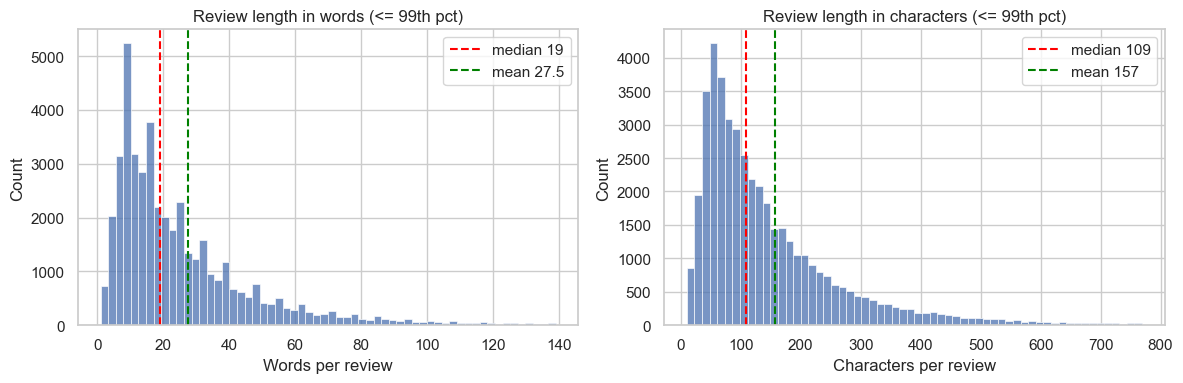

In [7]:
df_clean["char_len"] = df_clean["Review Text"].str.len()
df_clean["word_count"] = df_clean["Review Text"].str.split().apply(len)
print(df_clean[["char_len", "word_count"]].describe())

wc, cl = df_clean["word_count"], df_clean["char_len"]
wc_p99, cl_p99 = wc.quantile(0.99), cl.quantile(0.99)
print(f"99th pct words: {wc_p99:.0f}, reviews above: {(wc > wc_p99).sum()}")
print(f"99th pct chars: {cl_p99:.0f}, reviews above: {(cl > cl_p99).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(wc[wc <= wc_p99], bins=60, ax=axes[0])
axes[0].axvline(wc.median(), color="red", linestyle="--", label=f"median {wc.median():.0f}")
axes[0].axvline(wc.mean(), color="green", linestyle="--", label=f"mean {wc.mean():.1f}")
axes[0].set_title("Review length in words (<= 99th pct)")
axes[0].set_xlabel("Words per review"); axes[0].legend()
sns.histplot(cl[cl <= cl_p99], bins=60, ax=axes[1])
axes[1].axvline(cl.median(), color="red", linestyle="--", label=f"median {cl.median():.0f}")
axes[1].axvline(cl.mean(), color="green", linestyle="--", label=f"mean {cl.mean():.0f}")
axes[1].set_title("Review length in characters (<= 99th pct)")
axes[1].set_xlabel("Characters per review"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/review_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (5.6).** Reviews are short and right-skewed: the median is 19 words (109 characters) and the mean 27.5 words (156.6 characters). The mean sits above the median, with a maximum of 866 words against a 75th percentile of 34, confirming a long tail. The shortest reviews are a single word, so a minimum-length filter is considered in preprocessing to drop uninformative documents from the topic model. The bulk of reviews are short enough for standard vectoriser settings. The small tail beyond the 99th percentile needs no truncation and is naturally down-weighted by TF-IDF and bounded by document-frequency limits.

### 5.7 Top Unigrams Before and After Stopword Removal

Comparing the most frequent single words with and without stopword removal confirms the need for preprocessing and previews the corpus vocabulary. The raw frequency list should be dominated by function words; removing stopwords should surface domain-relevant and sentiment-bearing terms (Bird, Klein and Loper, 2009). `CountVectorizer` is used for efficient term counting (scikit-learn developers, 2024).

Top 20 unigrams (with stopwords):
  and: 51718
  the: 44867
  to: 43156
  was: 31898
  my: 24122
  very: 19526
  with: 18318
  for: 16172
  of: 13933
  me: 13283
  easy: 12144
  it: 11355
  in: 11195
  is: 10116
  insurance: 9875
  have: 9780
  that: 9653
  you: 9410
  service: 8885
  had: 8075

Top 20 unigrams (stopwords removed):
  easy: 12144
  insurance: 9875
  service: 8885
  great: 8038
  process: 7404
  helpful: 7214
  policy: 5178
  customer: 4959
  thank: 4827
  company: 4814
  questions: 4540
  would: 4327
  coverage: 4069
  professional: 4055
  time: 3943
  experience: 3818
  good: 3727
  get: 3563
  quick: 3541
  excellent: 3532


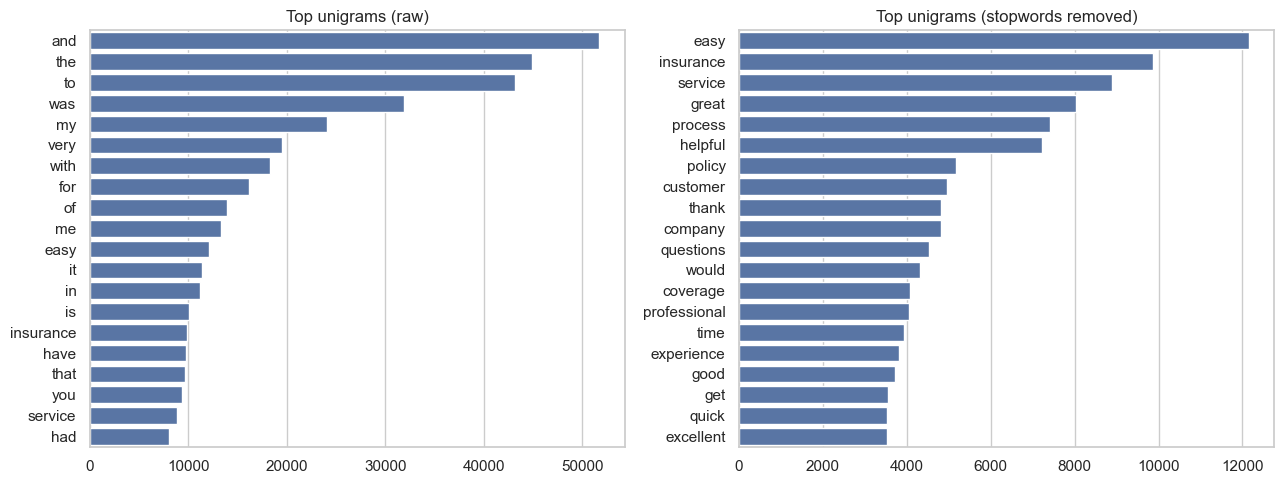

In [8]:
def top_terms(corpus, stop_words, n=20):
    vec = CountVectorizer(stop_words=stop_words, lowercase=True)
    X = vec.fit_transform(corpus)
    sums = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    order = sums.argsort()[::-1][:n]
    return [(terms[i], int(sums[i])) for i in order]

raw_top = top_terms(df_clean["Review Text"], stop_words=None, n=20)
clean_top = top_terms(df_clean["Review Text"], stop_words=list(STOPWORDS), n=20)
print("Top 20 unigrams (with stopwords):")
for t, c in raw_top: print(f"  {t}: {c}")
print("\nTop 20 unigrams (stopwords removed):")
for t, c in clean_top: print(f"  {t}: {c}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rt, rc = zip(*raw_top); ct, cc = zip(*clean_top)
sns.barplot(x=list(rc), y=list(rt), ax=axes[0]); axes[0].set_title("Top unigrams (raw)")
sns.barplot(x=list(cc), y=list(ct), ax=axes[1]); axes[1].set_title("Top unigrams (stopwords removed)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_unigrams_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (5.7).** The raw top-20 is dominated by function words (*and*, *the*, *to*, *was*, *my*, *with*, *for*, *of*). These carry no thematic or sentiment signal, confirming that stopword removal is required. With stopwords removed, two patterns emerge. Domain terms describe the service: *insurance*, *service*, *process*, *policy*, *customer*, *coverage*, *company*, *experience*. Evaluative terms are overwhelmingly positive: *easy*, *great*, *helpful*, *professional*, *good*, *quick*, *excellent*. This previews the likely topic vocabulary and confirms the corpus skews positive, which is why concern areas are identified by cross-analysing full-corpus topics against the negative sentiment rate, as planned in Sections 2 and 3.

### 5.8 Top Bigrams

Two-word phrases (bigrams) surface collocations that single-word counts miss, hinting at recurring service themes and evaluative expressions likely to appear as LDA topics (Bird, Klein and Loper, 2009). The cell below extracts the top 20 bigrams after stopword removal using `CountVectorizer` with `ngram_range=(2, 2)` (scikit-learn developers, 2024).

Top 20 bigrams (stopwords removed):
  customer service: 3814
  jewelers mutual: 1440
  answered questions: 1379
  highly recommend: 1294
  quick easy: 1114
  insurance company: 895
  would recommend: 874
  easy use: 862
  great customer: 851
  process easy: 817
  great service: 782
  application process: 715
  excellent service: 708
  life insurance: 701
  great experience: 695
  easy process: 692
  liability insurance: 688
  extremely helpful: 573
  excellent customer: 550
  great job: 541


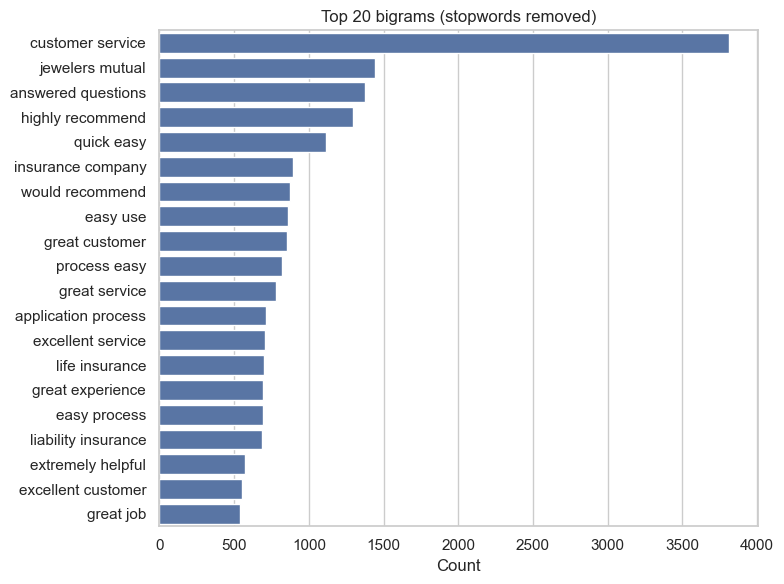

In [9]:
def top_ngrams(corpus, ngram_range, stop_words, n=20):
    vec = CountVectorizer(stop_words=stop_words, lowercase=True, ngram_range=ngram_range)
    X = vec.fit_transform(corpus)
    sums = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    order = sums.argsort()[::-1][:n]
    return [(terms[i], int(sums[i])) for i in order]

bigrams = top_ngrams(df_clean["Review Text"], (2, 2), list(STOPWORDS), 20)
print("Top 20 bigrams (stopwords removed):")
for t, c in bigrams: print(f"  {t}: {c}")
bt, bc = zip(*bigrams)
plt.figure(figsize=(8, 6))
sns.barplot(x=list(bc), y=list(bt))
plt.title("Top 20 bigrams (stopwords removed)"); plt.xlabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (5.8).** The most frequent bigram is *customer service* (3,814), the clearest service theme. Process and onboarding phrases follow (*answered questions*, *application process*, *process easy*, *quick easy*, *easy use*), alongside product types (*insurance company*, *life insurance*, *liability insurance*). Many top bigrams are positive and evaluative (*highly recommend*, *would recommend*, *great service*, *excellent service*, *great experience*, *excellent customer*, *great job*, *extremely helpful*), reinforcing the positive skew seen in the unigrams. *jewelers mutual* (1,440) is a brand name, showing the corpus contains specific insurer names; such entity tokens are watched in the topic model because brand names can form non-thematic topics, and a decision on keeping or filtering them is noted for preprocessing. Together these preview likely topics: customer service, application and onboarding process, and satisfaction or recommendation, with product-type terms as secondary signals.

### 5.9 Word Cloud

A word cloud gives a visual summary of the most frequent terms after stopword removal (Mueller, 2020). It is illustrative rather than quantitative, offering a gestalt of the vocabulary that complements the bar charts above (Hunter, 2007).

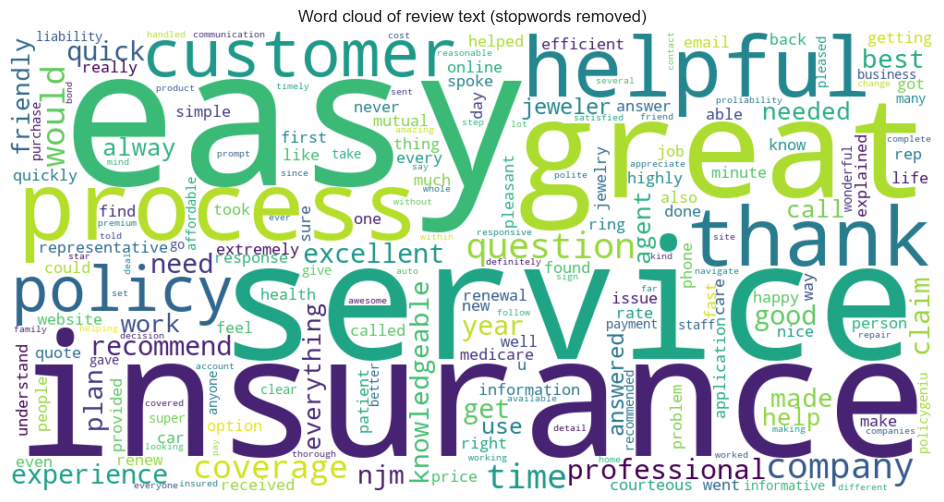

In [10]:
text_blob = " ".join(df_clean["Review Text"].str.lower())
wc_img = WordCloud(width=1000, height=500, background_color="white",
                   stopwords=STOPWORDS, collocations=False).generate(text_blob)
plt.figure(figsize=(12, 6))
plt.imshow(wc_img, interpolation="bilinear"); plt.axis("off")
plt.title("Word cloud of review text (stopwords removed)")
plt.savefig(f"{FIG_DIR}/wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (5.9).** The largest terms (*insurance*, *service*, *easy*, *helpful*, *process*, *great*, *policy*, *customer*, *company*, *question*, *professional*, *coverage*) match the top-unigram analysis. The visual agrees with the quantitative counts, and positive evaluative words again dominate (*easy*, *great*, *helpful*, *excellent*, *professional*, *recommend*). A word cloud sizes terms by raw frequency and is illustrative only; the bar charts and counts remain the quantitative basis for any conclusion.

### 5.10 Customer Location Breakdown

`Customer Location` is retained for descriptive context only and is not a model feature. The cell below shows the top 10 locations by review count, providing geographic context and relating to the proxy limitation noted in Section 2 (McKinney, 2022).

Customer Location
US    40214
CR     2245
BA     2228
Name: count, dtype: int64


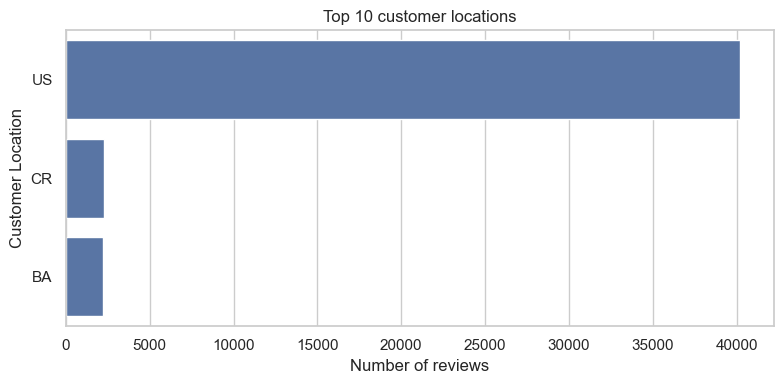

In [11]:
loc_counts = df_clean["Customer Location"].value_counts().head(10)
print(loc_counts)
plt.figure(figsize=(8, 4))
sns.barplot(x=loc_counts.values, y=loc_counts.index)
plt.title("Top 10 customer locations"); plt.xlabel("Number of reviews")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/customer_location_top10.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (5.10).** The data resolves to only three location codes: the US accounts for 40,214 of 44,687 reviews (about 90 percent), with CR and BA making up roughly five percent each. Location is highly concentrated. It is used only as descriptive context, not as a model feature. This confirms the proxy limitation from Section 2: the corpus is US-centric and not South African, so findings transfer to the medical-aid scenario by analogy rather than directly.

### 5.11 EDA Summary

The cleaned corpus is 44,687 unique insurance service reviews with no missing values. The reviews are treated as English for the NLP pipeline; no automated language detection was run. Key findings:

- **Length:** reviews are short and right-skewed (median 19 words, mean 27.5), with a single-word minimum and a small tail (about one percent) above 139 words. A minimum-length filter is applied in preprocessing. The small tail needs no truncation.
- **Vocabulary:** service and process domain terms dominate (*insurance*, *service*, *process*, *policy*, *customer*, *coverage*), alongside strongly positive evaluative terms (*easy*, *great*, *helpful*, *professional*, *excellent*). The corpus skews positive.
- **Themes:** bigrams point to customer service, application and onboarding process, and satisfaction or recommendation as likely topics. Specific insurer brand names (for example *jewelers mutual*) are present and will be monitored in the topic model.
- **Geography:** about 90 percent of reviews are from the US, confirming the proxy limitation.

These findings shape preprocessing. Text will be lowercased, stripped of URLs, HTML, punctuation, and digits, then stopword-removed and lemmatised for topic modelling. Very short reviews will be dropped. VADER sentiment labels will be derived from the original review text rather than the cleaned text, to preserve the capitalisation and punctuation cues VADER uses (Hutto and Gilbert, 2014). Because the corpus skews positive, the derived sentiment classes will be imbalanced: the sentiment model will use a stratified split, class weighting, and macro-averaged and negative-recall metrics. Areas of concern will be identified by cross-analysing full-corpus topics against the negative sentiment rate, with complaint vocabulary drawn from the negative subset in Section 11.

## 6. Text Preprocessing

The preprocessing function lowercases each review, strips URLs and HTML tags, retains only alphabetic tokens (removing digits and punctuation), removes English stopwords, and lemmatises each remaining token using the NLTK `WordNetLemmatizer` (Bird, Klein and Loper, 2009). Two deliberate decisions apply:

1. **Negation words are retained.** Words such as *not*, *no*, *never*, and *cannot* are excluded from the stopword removal list because they invert the sentiment of adjacent terms (e.g. "not helpful" versus "helpful") and are critical for the sentiment classification task.
2. **The original `Review Text` column is preserved unchanged.** VADER sentiment scoring relies on capitalisation, punctuation, and exclamation marks as intensity cues (Hutto and Gilbert, 2014), so the raw text is kept intact for VADER labelling in Section 7. The cleaned `clean_text` column is used for topic modelling and as input to the supervised TF-IDF pipeline.

### 6.1 Build and Apply the Cleaning Function

The cell below defines the `preprocess` function and applies it to every review, creating a new `clean_text` column. The negation set is subtracted from the NLTK stopword list so that sentiment-inverting words survive the cleaning pipeline (Bird, Klein and Loper, 2009).

In [12]:
NEGATION = {"no", "not", "nor", "never", "none", "cannot", "nothing", "neither"}
STOPWORDS_KEEP_NEG = STOPWORDS - NEGATION

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    tokens = re.findall(r"[a-z]+", text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS_KEEP_NEG and len(t) > 1]
    return " ".join(tokens)

df_clean["clean_text"] = df_clean["Review Text"].apply(preprocess)
print("clean_text created. Example:")
print(df_clean["clean_text"].iloc[0][:200])

clean_text created. Example:
easy use understand quick result affordable


### 6.2 Minimum-Length Filter

Reviews that reduce to fewer than three cleaned tokens carry too little information for topic or sentiment analysis. The cell below removes them, as flagged in the EDA summary (Section 5.11).

In [13]:
df_clean["clean_token_count"] = df_clean["clean_text"].str.split().apply(len)
before = len(df_clean)
df_clean = df_clean[df_clean["clean_token_count"] >= 3].reset_index(drop=True)
print(f"Reviews before min-length filter: {before}")
print(f"Removed (fewer than 3 cleaned tokens): {before - len(df_clean)}")
print(f"Reviews remaining for modelling: {len(df_clean)}")

Reviews before min-length filter: 44687
Removed (fewer than 3 cleaned tokens): 857
Reviews remaining for modelling: 43830


### 6.3 Before and After Examples

The cell below prints three raw/cleaned review pairs so the cleaning behaviour can be visually verified.

In [14]:
for i in [0, 1, 2]:
    print(f"RAW  : {df_clean['Review Text'].iloc[i][:160]}")
    print(f"CLEAN: {df_clean['clean_text'].iloc[i][:160]}")
    print("-" * 80)

RAW  : Easy to use and understand! Quick results and affordable!
CLEAN: easy use understand quick result affordable
--------------------------------------------------------------------------------
RAW  : It was a real pleasure to speak with Victoria about your interesting options for travel insurance, in particular the "Safe Travel International Cost Saver" opti
CLEAN: real pleasure speak victoria interesting option travel insurance particular safe travel international cost saver option victoria recommended insurance need able
--------------------------------------------------------------------------------
RAW  : Byron Preston was super helpful in explaining what documents I will need from my policy and updating my application to include my passport number. Going forward
CLEAN: byron preston super helpful explaining document need policy updating application include passport number going forward time fill costa rica travel passport know
--------------------------------------------------

**Interpretation (6.3).** Preprocessing reduces each review to lemmatised content words while retaining negation for the sentiment task. The minimum-length filter removes the very short reviews flagged in EDA (the exact count is printed above), leaving the corpus used for both topic modelling and the sentiment classifier. The original `Review Text` column stays intact for VADER labelling. The before-and-after examples confirm the cleaning behaves as intended.

## 7. Sentiment Labelling with VADER

The dataset has no rating or score column (confirmed in Section 5.4). Sentiment labels are derived using VADER (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-and-rule model built for short, informal review and social-media text (Hutto and Gilbert, 2014). VADER is applied to the **original** `Review Text` column, not the cleaned text, to preserve the capitalisation, punctuation, and intensity cues it relies on (e.g. "GREAT!!!" scores higher than "great").

The compound score maps to three classes using the standard thresholds from Hutto and Gilbert (2014): compound >= 0.05 is **positive**, compound <= −0.05 is **negative**, and scores between these thresholds are **neutral**.

These are derived (proxy) labels, not human annotations. Downstream evaluation metrics therefore measure the supervised model's agreement with this lexicon baseline rather than with human ground truth. A manual sample is validated below, and the limitation is carried into the evaluation section.

### 7.1 Derive Sentiment Labels

The cell below applies VADER's `polarity_scores` to each original review, extracts the compound score, and maps it to a three-class label. The class distribution is printed and visualised (Hutto and Gilbert, 2014; Waskom, 2021).

           count  percent
sentiment                
positive   38812     88.6
negative    2674      6.1
neutral     2344      5.3


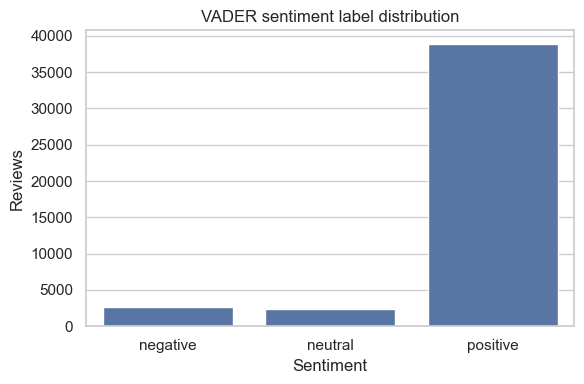

In [15]:
sia = SentimentIntensityAnalyzer()
df_clean["vader_compound"] = df_clean["Review Text"].apply(
    lambda t: sia.polarity_scores(str(t))["compound"])

def to_label(c):
    if c >= 0.05: return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

df_clean["sentiment"] = df_clean["vader_compound"].apply(to_label)
dist = df_clean["sentiment"].value_counts()
pct = df_clean["sentiment"].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([dist, pct], axis=1, keys=["count", "percent"]))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="sentiment", order=["negative", "neutral", "positive"])
plt.title("VADER sentiment label distribution"); plt.xlabel("Sentiment"); plt.ylabel("Reviews")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Manual Validation Sample

Five reviews per sentiment class are printed so the assigned VADER labels can be checked by eye against the text. This manual spot-check is the primary mitigation for the lexicon-derived label limitation noted above and in Section 2.

In [16]:
sample = df_clean.groupby("sentiment").sample(n=5, random_state=RANDOM_STATE)
for _, r in sample.iterrows():
    print(f"[{r['sentiment']} | compound {r['vader_compound']:.3f}] {r['Review Text'][:170]}")
    print("-" * 80)

[negative | compound -0.296] The application process was straight forward. The extensive FAQ and guides on the website were informative and helpful to make a decision. They have a sample policy on th
--------------------------------------------------------------------------------
[negative | compound -0.340] last year I struggled to renew my policy - this year the process was quick
--------------------------------------------------------------------------------
[negative | compound -0.440] I had to update my address and I was locked out of my account after choosing "Edit". This was frustrating
--------------------------------------------------------------------------------
[negative | compound -0.226] From the time I called NJM to report my claim, to it being assigned to Jennifer C, to her timely communicating with me and sharing documents via email, to her settling th
--------------------------------------------------------------------------------
[negative | compound -0.566] NJM uses

**Interpretation (7.2).** The labels skew strongly positive (38,812; 88.6 percent), with negative (2,674; 6.1 percent) and neutral (2,344; 5.3 percent) small. VADER's positive class is reliable, but the negative and neutral classes are noisy. Several neutral-scored reviews are mildly positive (praise such as "knowledgeable", "fast and simple", and "reasonable rate, five stars") that VADER scored 0.000 because the praise vocabulary falls outside its lexicon. Conversely, some positive reviews were scored negative where insurance terms such as *claim*, *loss* and *struggled* carry negative lexicon weight. Because the positive boundary is unreliable and the client's need is to detect dissatisfaction, the supervised model uses a binary target (negative versus non-negative), while the three-class distribution above is retained as a descriptive sentiment overview. Merging neutral into non-negative absorbs the neutral ambiguity correctly. The labels remain lexicon-derived, so downstream metrics measure agreement with VADER rather than human ground truth. This limitation is carried into the evaluation and limitations sections.

### 7.3 Modelling Target: Binary Sentiment

Based on the validation findings above, the supervised sentiment model uses a **binary target**: *negative* versus *non-negative* (positive and neutral merged). This focuses the classifier on the client's priority, detecting dissatisfied customers, and absorbs the noisy neutral boundary into the majority class, where it causes least harm.

                  count  percent
sentiment_binary                
non-negative      41156     93.9
negative           2674      6.1


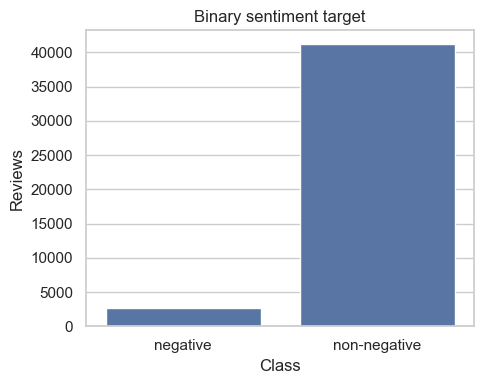

In [17]:
df_clean["sentiment_binary"] = np.where(df_clean["sentiment"] == "negative",
                                        "negative", "non-negative")
dist = df_clean["sentiment_binary"].value_counts()
pct = df_clean["sentiment_binary"].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([dist, pct], axis=1, keys=["count", "percent"]))
plt.figure(figsize=(5, 4))
sns.countplot(data=df_clean, x="sentiment_binary", order=["negative", "non-negative"])
plt.title("Binary sentiment target"); plt.xlabel("Class"); plt.ylabel("Reviews")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_binary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (7.3).** The negative class is a small minority of the corpus (printed above). The sentiment pipeline therefore uses a stratified train/test split, `class_weight='balanced'`, and macro F1 and negative-class recall as the primary metrics rather than accuracy, which would be misleading at this imbalance.

## 8. Topic Modelling with LDA

Latent Dirichlet Allocation (LDA) is a probabilistic generative model that represents each document as a mixture of topics and each topic as a distribution over words (Blei, Ng and Jordan, 2003). Short reviews may raise several concerns at once, and LDA captures this as topic mixtures. The resulting topics are interpretable, addressing the areas-of-concern question posed in Section 1. NMF and LSA produce components but lack LDA's probabilistic topic mixtures, which are more directly interpretable for this task. The topic count is chosen empirically: models are trained over a range of topic counts and scored by c_v coherence (Rehurek and Sojka, 2010), supported by perplexity and human interpretability.

### 8.1 Feature Extraction for LDA

LDA models word counts, so a `CountVectorizer` is used rather than TF-IDF. Setting `min_df=20` and `max_df=0.5` drops very rare tokens (such as individual names that survived preprocessing) and ubiquitous terms, improving topic quality and training speed (scikit-learn developers, 2024).

In [18]:
count_vec = CountVectorizer(min_df=20, max_df=0.5)
X_counts = count_vec.fit_transform(df_clean["clean_text"])
vocab = count_vec.get_feature_names_out()
print(f"LDA document-term matrix: {X_counts.shape[0]} docs x {X_counts.shape[1]} terms")

LDA document-term matrix: 43830 docs x 2275 terms


**Interpretation (8.1).** The document-frequency limits reduce the vocabulary to the size printed above, removing rare entity tokens and over-common words so topics rest on meaningful, moderately frequent terms.

### 8.2 Selecting the Number of Topics

LDA is fit for a range of topic counts (k = 4, 6, 8, 10, 12, 14). Each model is scored by c_v coherence (primary), which measures the semantic similarity of the top words within each topic (Rehurek and Sojka, 2010), and by perplexity (secondary). The final topic count also requires human judgement on interpretability, applied in the next step.

k=4: coherence c_v = 0.4396 | perplexity = 694.1
k=6: coherence c_v = 0.5472 | perplexity = 744.9
k=8: coherence c_v = 0.5816 | perplexity = 775.2
k=10: coherence c_v = 0.5506 | perplexity = 827.7
k=12: coherence c_v = 0.5357 | perplexity = 864.6
k=14: coherence c_v = 0.5351 | perplexity = 900.6


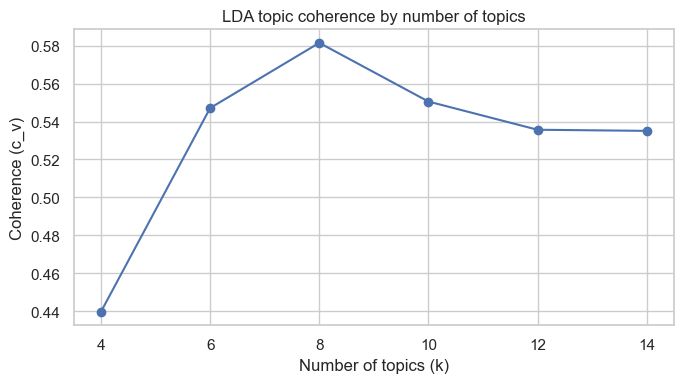

In [19]:
texts = [doc.split() for doc in df_clean["clean_text"]]
dictionary = Dictionary(texts)

def lda_top_words(model, feature_names, topn=10):
    return [[feature_names[i] for i in topic.argsort()[::-1][:topn]]
            for topic in model.components_]

topic_range = [4, 6, 8, 10, 12, 14]
coherence_scores = []
for k in topic_range:
    lda = LatentDirichletAllocation(n_components=k, random_state=RANDOM_STATE,
                                    learning_method="online", max_iter=10)
    lda.fit(X_counts)
    topics = lda_top_words(lda, vocab, topn=10)
    cm = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    perp = lda.perplexity(X_counts)
    coherence_scores.append(score)
    print(f"k={k}: coherence c_v = {score:.4f} | perplexity = {perp:.1f}")

plt.figure(figsize=(7, 4))
plt.plot(topic_range, coherence_scores, marker="o")
plt.xlabel("Number of topics (k)"); plt.ylabel("Coherence (c_v)")
plt.title("LDA topic coherence by number of topics")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/lda_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (8.2).** Coherence peaks at k=8 (c_v = 0.5816), rising from 0.4396 at k=4 and easing gradually beyond eight (0.5506 at k=10, 0.5357 at k=12, 0.5351 at k=14). Perplexity increases monotonically with k (from 694 at k=4 to 901 at k=14), so it favours fewer topics and diverges from coherence. Perplexity measures held-out fit rather than human interpretability, and the two are known to disagree (Chang et al., 2009). Coherence and interpretability are therefore prioritised. Eight topics are selected as the coherence maximum.

### 8.3 Final LDA Model and Topic Inspection

LDA is refit with eight topics using `learning_method='batch'` and 25 iterations for a more stable final solution than the quick online sweep used for selection. The top 12 words per topic are printed for human labelling, and the number of reviews assigned to each dominant topic is reported to show topic prevalence (Blei, Ng and Jordan, 2003; scikit-learn developers, 2024).

Loaded cached LDA model and document-topic matrix.
Topic 0: service, company, recommend, great, insurance, always, customer, would, highly, best, year, excellent
Topic 1: easy, process, quick, insurance, coverage, use, price, fast, simple, great, website, online
Topic 2: plan, insurance, best, need, option, medicare, help, helped, health, coverage, right, helpful
Topic 3: helpful, question, service, professional, great, knowledgeable, answered, customer, representative, thank, excellent, friendly
Topic 4: claim, njm, car, repair, handled, quickly, everything, care, day, shop, vehicle, auto
Topic 5: not, policy, time, insurance, would, get, call, company, no, email, year, one
Topic 6: process, easy, made, application, policygenius, policy, quick, minute, time, bond, step, life
Topic 7: jeweler, service, mutual, jewelry, no, claim, ring, customer, never, year, excellent, insured

Documents per dominant topic:
dominant_topic
0    6500
1    7326
2    4863
3    9076
4    2496
5    6374
6   

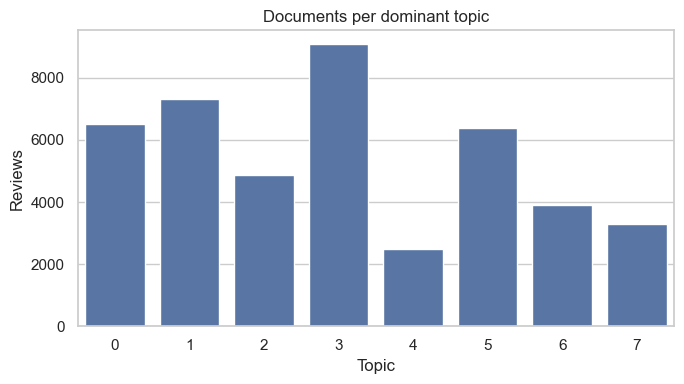

In [20]:
import joblib
N_TOPICS = 8
LDA_CACHE = "lda_model.joblib"
DT_CACHE = "doc_topic.joblib"

if os.path.exists(LDA_CACHE) and os.path.exists(DT_CACHE):
    lda_final = joblib.load(LDA_CACHE)
    doc_topic = joblib.load(DT_CACHE)
    print("Loaded cached LDA model and document-topic matrix.")
else:
    lda_final = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                          learning_method="batch", max_iter=25)
    doc_topic = lda_final.fit_transform(X_counts)
    joblib.dump(lda_final, LDA_CACHE)
    joblib.dump(doc_topic, DT_CACHE)
    print("Fitted and cached LDA model and document-topic matrix.")

def print_top_words(model, feature_names, topn=12):
    for idx, topic in enumerate(model.components_):
        top = [feature_names[i] for i in topic.argsort()[::-1][:topn]]
        print(f"Topic {idx}: {', '.join(top)}")

print_top_words(lda_final, vocab, topn=12)
df_clean["dominant_topic"] = doc_topic.argmax(axis=1)
prev = df_clean["dominant_topic"].value_counts().sort_index()
print("\nDocuments per dominant topic:")
print(prev)
plt.figure(figsize=(7, 4))
sns.barplot(x=prev.index, y=prev.values)
plt.title("Documents per dominant topic"); plt.xlabel("Topic"); plt.ylabel("Reviews")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/topic_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (8.3).** The eight topics fall into three groups. **Praise:** Topic 0 (general satisfaction and recommendation) and Topic 3 (agent helpfulness and professionalism). **Process and onboarding:** Topic 1 (ease and speed of the online process), Topic 2 (plan and coverage selection, including health and Medicare), and Topic 6 (application and onboarding process). **Claims and concerns:** Topic 4 (auto claims handling), Topic 7 (jewelry insurance and claims, dominated by the Jewelers Mutual brand), and Topic 5 (policy, contact and communication problems). Topic 5 is the clearest dissatisfaction theme. Its top words include the negations "not" and "no" alongside "policy", "call", "email" and "time", pointing to problems reaching the company and resolving policy issues. By prevalence the corpus is led by praise and ease themes (Topic 3 with 9,076 reviews, Topic 1 with 7,326, Topic 0 with 6,500), consistent with the positive skew. The leading concern theme (Topic 5, 6,374 reviews) is the fourth most prevalent, showing that policy and communication problems are a substantial minority. These labelled topics answer the areas-of-concern question and are linked to sentiment in the cross-analysis.

### 8.4 Topic Labelling

The table below assigns a business-meaningful label to each topic based on the top-word inspection in Section 8.3 and groups them by theme.

| Topic | Top words (summary) | Label | Group |
|---|---|---|---|
| 0 | recommend, great, excellent, best, service | General satisfaction and recommendation | Praise |
| 1 | easy, quick, online, website, fast, price | Ease and speed of the online process | Process |
| 2 | plan, medicare, health, coverage, option | Plan and coverage selection | Process |
| 3 | helpful, professional, knowledgeable, representative | Agent helpfulness and professionalism | Praise |
| 4 | claim, car, repair, vehicle, njm | Auto claims handling | Claims |
| 5 | not, no, policy, call, email, time | Policy, contact and communication problems | Concern |
| 6 | application, policygenius, step, life, bond | Application and onboarding process | Process |
| 7 | jeweler, jewelry, ring, mutual, claim | Jewelry insurance and claims (Jewelers Mutual) | Product and claims |

In [21]:
TOPIC_LABELS = {
    0: "General satisfaction and recommendation",
    1: "Ease and speed of the online process",
    2: "Plan and coverage selection",
    3: "Agent helpfulness and professionalism",
    4: "Auto claims handling",
    5: "Policy, contact and communication problems",
    6: "Application and onboarding process",
    7: "Jewelry insurance and claims (Jewelers Mutual)",
}
df_clean["topic_label"] = df_clean["dominant_topic"].map(TOPIC_LABELS)
print(df_clean["topic_label"].value_counts())

topic_label
Agent helpfulness and professionalism             9076
Ease and speed of the online process              7326
General satisfaction and recommendation           6500
Policy, contact and communication problems        6374
Plan and coverage selection                       4863
Application and onboarding process                3898
Jewelry insurance and claims (Jewelers Mutual)    3297
Auto claims handling                              2496
Name: count, dtype: int64


## 9. Sentiment Classification Pipeline

A supervised scikit-learn `Pipeline` (Pedregosa et al., 2011) predicts the binary sentiment target (negative versus non-negative) from TF-IDF features. `TfidfVectorizer` uses unigrams and bigrams so that negation phrases such as "not helpful" are captured as features, and down-weights ubiquitous terms that carry little discriminative signal (scikit-learn developers, 2024).

Three linear classifiers suited to high-dimensional sparse text are compared:

1. **Multinomial Naive Bayes**, a fast probabilistic baseline assuming conditional independence of features given the class.
2. **Logistic Regression**, a discriminative linear model with `class_weight='balanced'` to counter the approximately 6 percent negative class.
3. **Linear SVM** (`LinearSVC`), a maximum-margin classifier, also with `class_weight='balanced'`.

Deep learning is unnecessary at this corpus size and would add heavy dependencies without a proportionate gain. Tree ensembles (Random Forest, Gradient Boosting) are weaker on very high-dimensional sparse text features than linear models (scikit-learn developers, 2024).

### 9.1 Train and Test Split

The data is split 80/20 with stratification on the binary target to preserve the class ratio in both sets. The split operates on the cleaned text column; TF-IDF vectorisation happens inside the pipeline so no information leaks from test to train (scikit-learn developers, 2024).

In [22]:
X = df_clean["clean_text"]
y = df_clean["sentiment_binary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train: 35064, Test: 8766
Train class balance:
sentiment_binary
non-negative    0.939
negative        0.061
Name: proportion, dtype: float64
Test class balance:
sentiment_binary
non-negative    0.939
negative        0.061
Name: proportion, dtype: float64


### 9.2 Model Comparison

The three pipelines are compared with stratified 5-fold cross-validation on the training set. Scoring uses macro F1 and negative-class recall, because accuracy is misleading under the class imbalance established in Section 7.3 (scikit-learn developers, 2024).

In [23]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score, make_scorer

def make_pipe(clf):
    return Pipeline([("tfidf", TfidfVectorizer(min_df=5, ngram_range=(1, 2))), ("clf", clf)])

models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000,
                                             random_state=RANDOM_STATE),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"macro_f1": "f1_macro",
           "negative_recall": make_scorer(recall_score, pos_label="negative")}
rows = []
for name, clf in models.items():
    res = cross_validate(make_pipe(clf), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name,
                 "macro_f1": res["test_macro_f1"].mean(),
                 "macro_f1_std": res["test_macro_f1"].std(),
                 "negative_recall": res["test_negative_recall"].mean()})
    print(f"{name}: macro-F1 {rows[-1]['macro_f1']:.3f} "
          f"(+/- {rows[-1]['macro_f1_std']:.3f}), negative recall {rows[-1]['negative_recall']:.3f}")
comparison = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
print()
print(comparison.to_string(index=False))

MultinomialNB: macro-F1 0.517 (+/- 0.014), negative recall 0.034
LogisticRegression: macro-F1 0.768 (+/- 0.005), negative recall 0.839
LinearSVC: macro-F1 0.795 (+/- 0.006), negative recall 0.699

             model  macro_f1  macro_f1_std  negative_recall
         LinearSVC  0.794581      0.006116         0.699389
LogisticRegression  0.767649      0.004783         0.839170
     MultinomialNB  0.516832      0.014027         0.033665


**Interpretation (9.2).** LinearSVC has the best macro-F1 (0.795) and Logistic Regression the best negative recall (0.839). The two metrics disagree: LinearSVC edges macro-F1, but Logistic Regression catches far more of the negative class (0.839 versus 0.699). Multinomial Naive Bayes is poor on the negative class (recall 0.034) because, without class weighting, it defaults to the majority class under this imbalance. It is dropped. Logistic Regression is taken forward for tuning. The client's priority is detecting dissatisfaction, where negative recall matters most and Logistic Regression leads clearly, at only a small macro-F1 cost. It also provides probability estimates for later threshold control and interpretable coefficients showing which words drive negative sentiment.

### 9.3 Hyperparameter Tuning

The Logistic Regression pipeline is tuned with `GridSearchCV` over TF-IDF and regularisation settings, scored on macro-F1 with stratified 5-fold cross-validation. The search covers ngram range, minimum document frequency, and the regularisation strength C. The result is cached with joblib so the grid is not refit on every kernel restart (scikit-learn developers, 2024).

In [24]:
from sklearn.model_selection import GridSearchCV
GS_CACHE = "sentiment_model.joblib"
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if os.path.exists(GS_CACHE):
    bundle = joblib.load(GS_CACHE)
    best_model, best_params, best_score = bundle["model"], bundle["params"], bundle["score"]
    print("Loaded cached tuned sentiment model.")
else:
    param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [3, 5],
        "clf__C": [0.5, 1.0, 2.0],
    }
    base_pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000,
                                   random_state=RANDOM_STATE)),
    ])
    grid = GridSearchCV(base_pipe, param_grid, scoring="f1_macro", cv=cv5, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    best_model, best_params, best_score = grid.best_estimator_, grid.best_params_, grid.best_score_
    joblib.dump({"model": best_model, "params": best_params, "score": best_score}, GS_CACHE)
    print("Fitted and cached tuned sentiment model.")

print("Best params:", best_params)
print(f"Best CV macro-F1: {best_score:.3f}")

Loaded cached tuned sentiment model.
Best params: {'clf__C': 2.0, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.783


**Interpretation (9.3).** GridSearchCV selected bigrams (ngram_range (1, 2)) over unigrams, a minimum document frequency of 3, and a regularisation strength C of 2.0. Choosing bigrams confirms that two-word features such as "not helpful" carry sentiment information unigrams miss. The lighter regularisation with the lower min_df admits a richer feature set. The tuned cross-validation macro-F1 is 0.783, a modest gain over the untuned Logistic Regression score of 0.768 (about 1.5 points), showing the defaults were already reasonable but that bigram features and lighter regularisation add measurable value.

## 10. Model Evaluation

The tuned Logistic Regression pipeline is assessed on the held-out test set, unseen during training or hyperparameter selection. The negative class is the focus. The client's priority is detecting dissatisfied customers, so negative-class recall and F1 are the primary metrics alongside macro-F1 (scikit-learn developers, 2024).

### 10.1 Test-Set Performance

The `best_model` returned by `GridSearchCV` is already refit on the full training set and is used directly for test-set prediction. The classification report, confusion matrix, and a confusion-matrix plot are produced below.

              precision    recall  f1-score   support

    negative      0.504     0.834     0.628       535
non-negative      0.989     0.947     0.967      8231

    accuracy                          0.940      8766
   macro avg      0.746     0.890     0.798      8766
weighted avg      0.959     0.940     0.947      8766

Confusion matrix [rows = true, cols = pred], order [negative, non-negative]:
[[ 446   89]
 [ 439 7792]]


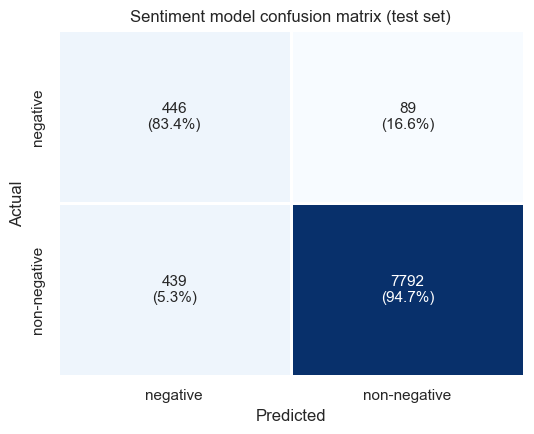

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))
cm = confusion_matrix(y_test, y_pred, labels=["negative", "non-negative"])
print("Confusion matrix [rows = true, cols = pred], order [negative, non-negative]:")
print(cm)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                  for rc, rp in zip(cm, cm_pct)])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
            xticklabels=["negative", "non-negative"],
            yticklabels=["negative", "non-negative"],
            linewidths=1, linecolor="white", annot_kws={"size": 11})
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Sentiment model confusion matrix (test set)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (10.1).** On the held-out test set the tuned model reaches a macro-F1 of 0.798 and accuracy of 0.940. For the negative class (the focus), precision is 0.504, recall is 0.834, and F1 is 0.628. The confusion matrix shows 446 of the 535 true negative reviews are caught and 89 are missed, while 439 non-negative reviews are flagged as negative. In client terms the model detects about 83 percent of dissatisfied customers, suiting a screening tool whose main risk is missing dissatisfaction. Roughly half of the reviews it flags are false alarms, so flagged reviews are best treated as a prioritised queue for human review rather than a final verdict. Lowering the decision threshold (possible because Logistic Regression outputs probabilities) would catch more of the 89 missed negatives at the cost of more false alarms. These metrics measure agreement with the VADER-derived labels rather than human judgement, the limitation carried from Sections 2 and 7.

### 10.2 Most Influential Terms

The Logistic Regression coefficients show which TF-IDF features push a review toward each class, providing interpretability a black-box model would not offer. In scikit-learn's binary setup the single coefficient vector corresponds to the second class in `classes_`, which here is non-negative: positive coefficients push toward non-negative, negative coefficients push toward negative (scikit-learn developers, 2024). The lists below are read on that basis.

In [26]:
tfidf_step = best_model.named_steps["tfidf"]
clf_step = best_model.named_steps["clf"]
feat = np.array(tfidf_step.get_feature_names_out())
coefs = clf_step.coef_[0]
print("Classes:", clf_step.classes_)
order = coefs.argsort()
print("\nTop 15 terms pushing toward NEGATIVE:")
print(", ".join(feat[order[:15]]))
print("\nTop 15 terms pushing toward NON-NEGATIVE:")
print(", ".join(feat[order[-15:]][::-1]))

Classes: ['negative' 'non-negative']

Top 15 terms pushing toward NEGATIVE:
no, nothing, not, difficult, problem, frustrating, terrible, accident, poor, wrong, damage, confusing, disappointed, hard, stress

Top 15 terms pushing toward NON-NEGATIVE:
easy, great, helpful, excellent, best, thank, efficient, thanks, nice, help, awesome, good, happy, care, courteous


**Interpretation (10.2).** The terms pushing toward the negative class are genuine dissatisfaction vocabulary: negations (*no*, *nothing*, *not*), problem words (*difficult*, *problem*, *wrong*, *hard*, *confusing*), emotional terms (*frustrating*, *terrible*, *disappointed*, *stress*), and domain-specific negatives (*accident*, *damage*). The negations confirm the value of retaining negation words and the bigram features chosen during tuning. The terms pushing toward non-negative are clear praise vocabulary (*easy*, *great*, *helpful*, *excellent*, *best*, *efficient*, *awesome*, *good*, *happy*, *courteous*), consistent with the EDA. The model learned linguistically coherent drivers rather than arbitrary tokens, giving confidence it captures real sentiment language and is not merely mimicking VADER. This transparency is a reason Logistic Regression was chosen over Linear SVM: the coefficients expose directly which language signals dissatisfaction, and the client can act on that information.

### 10.3 Error Analysis

Misclassified reviews are inspected to understand failure modes. False negatives are true negative reviews the model missed (predicted non-negative); false positives are non-negative reviews incorrectly flagged as negative. Sample reviews from each group are printed below.

In [27]:
test_df = pd.DataFrame({
    "review": df_clean.loc[X_test.index, "Review Text"].values,
    "true": y_test.values,
    "pred": y_pred,
})
false_neg = test_df[(test_df["true"] == "negative") & (test_df["pred"] == "non-negative")]
false_pos = test_df[(test_df["true"] == "non-negative") & (test_df["pred"] == "negative")]
print(f"False negatives (missed negatives): {len(false_neg)}")
print(f"False positives (false alarms): {len(false_pos)}")
print("\n--- Sample missed negatives ---")
for r in false_neg["review"].head(5):
    print("-", r[:170])
print("\n--- Sample false alarms ---")
for r in false_pos["review"].head(5):
    print("-", r[:170])

False negatives (missed negatives): 89
False positives (false alarms): 439

--- Sample missed negatives ---
- Very expensive as compared to other options :(
- Totally inadequate for car insurance. I’m tired of wasting my time with this company. Save yourself some time and go directly thru progressive or geico or what ever major
- An encrypted form that was emailed to me could not be opened. Ms.Green was able to resolve this problem for me. Her professionalism was greatly appreciated.Thanks
- Expedited and professional. I never felt ‘sold’. Fair policy. Fair price
- Smooth process, all my questions were answered making me feel less anxious

--- Sample false alarms ---
- I called within 12 hours to cancel my application, I also faxed a letter right away. I asked my card not be charged. The policy stills show in effect and my card was char
- I lost an earring several years ago. No problems with getting taken care of. Very pleased.
- Even though the credit card charge went through, It neve

**Interpretation (10.3).** The errors split into two kinds. Some are genuine model mistakes: short or subtly worded complaints the bag-of-words model misses (for example "Very expensive as compared to other options"), and positive reviews flagged negative because they contain negatively weighted domain words such as *stress*, *lost*, *repairs* or *no* (for example "Very fast and stress free resolutions to the rental car"). These reflect the limits of a linear bag-of-words model that cannot read context. The more revealing pattern is that many apparent errors are cases where the VADER label is itself wrong and the model's prediction is more accurate. Several missed negatives are clearly positive reviews VADER had labelled negative because of words like "problem" or "never" (for example a review praising staff professionalism after a form failed to open, and "Expedited and professional, fair policy, fair price"). Some false alarms are genuine complaints VADER had labelled non-negative (for example a billing complaint about a charge after a cancellation). In these cases the classifier is penalised for disagreeing with a noisy label, so true performance is likely better than the headline metrics suggest. This reinforces the Section 7 limitation and supports using the model as a screening tool whose flags are reviewed by a person.

## 10.4 Evaluation Summary

Both models were tuned and evaluated. The coherence sweep in Section 8.2 selected eight coherent, interpretable topics. The sentiment model was chosen by comparing three classifiers (Section 9.2) and then tuned with GridSearchCV (Section 9.3), raising cross-validation macro-F1 from 0.768 to 0.783 through bigram features and lighter regularisation. On the held-out test set the tuned model reaches macro-F1 0.798 and catches about 83 percent of negative reviews, with negative precision near 0.50. This fits a screening tool that prioritises not missing dissatisfaction. The coefficient analysis shows the model learned coherent dissatisfaction and praise vocabulary. The error analysis shows a meaningful share of apparent errors are disagreements with noisy VADER labels rather than true mistakes, so real performance is likely somewhat better than the headline figures. All sentiment metrics measure agreement with lexicon-derived labels, not human judgement. This limitation is carried into the recommendations.

## 11. Cross-Analysis: Concerns and Sentiment

The topic and sentiment results are now combined to answer which areas of concern carry the most dissatisfaction, the core question for the client. Raw topic prevalence (Section 8.3) shows how common each theme is, but the client needs to know which themes are disproportionately negative. A common topic that is mostly positive (e.g. agent praise) is not a concern. The cross-analysis computes the negative sentiment rate within each topic and examines the vocabulary of the most strongly negative reviews.

### 11.1 Negative Sentiment Rate by Topic

The crosstab below shows, for each topic, the percentage of reviews classified as negative versus non-negative. Topics are sorted by descending negative rate so the most dissatisfied themes appear first.

sentiment_binary                                negative  non-negative
topic_label                                                           
Policy, contact and communication problems          23.9          76.1
Auto claims handling                                13.6          86.4
Jewelry insurance and claims (Jewelers Mutual)       9.3          90.7
Application and onboarding process                   3.0          97.0
Plan and coverage selection                          2.1          97.9
General satisfaction and recommendation              1.6          98.4
Ease and speed of the online process                 1.6          98.4
Agent helpfulness and professionalism                0.8          99.2


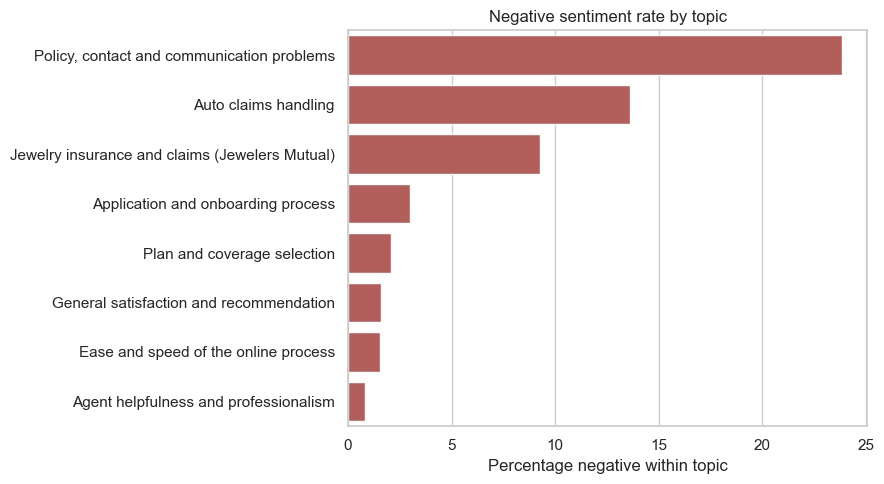

In [28]:
ct = pd.crosstab(df_clean["topic_label"], df_clean["sentiment_binary"], normalize="index").mul(100)
ct = ct.sort_values("negative", ascending=False)
print(ct.round(1))
plt.figure(figsize=(9, 5))
sns.barplot(x=ct["negative"], y=ct.index, color="#c0504d")
plt.xlabel("Percentage negative within topic"); plt.ylabel("")
plt.title("Negative sentiment rate by topic")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/negative_rate_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation (11.1).** Three topics carry almost all the dissatisfaction. Policy, contact and communication problems is the highest at 23.9 percent negative, ahead of auto claims handling (13.6 percent) and jewelry insurance and claims (9.3 percent). The remaining topics are overwhelmingly positive. Agent helpfulness is the lowest at 0.8 percent. This reranks the topics very differently from raw prevalence: agent helpfulness was the most prevalent topic (9,076 reviews) yet is the least negative, making it a clear strength. Policy, contact and communication problems was only fourth by prevalence (6,374 reviews) but is the most negative, making it the genuine priority. Combining rate and volume, policy and communication problems also produce the largest absolute number of negative reviews (roughly 1,500), well ahead of auto claims (about 340) and jewelry claims (about 310). The client should address policy and communication first, then claims handling, while protecting the agent and onboarding experiences that already perform well.

### 11.2 Complaint Vocabulary in Strongly Negative Reviews

The most frequent terms and bigrams in the strongly negative subset (VADER compound ≤ −0.3) are extracted to sharpen the areas-of-concern answer. This stricter threshold isolates reviews with clear dissatisfaction rather than borderline cases.

In [29]:
strict_neg = df_clean[df_clean["vader_compound"] <= -0.3]
print(f"Strongly negative reviews (compound <= -0.3): {len(strict_neg)}")
neg_terms = top_ngrams(strict_neg["clean_text"], (1, 2), None, 20)
print("Top terms and bigrams in strongly negative reviews:")
for t, c in neg_terms:
    print(f"  {t}: {c}")

Strongly negative reviews (compound <= -0.3): 1725
Top terms and bigrams in strongly negative reviews:
  not: 1139
  no: 721
  insurance: 610
  policy: 568
  time: 466
  company: 400
  claim: 383
  get: 377
  would: 365
  call: 333
  year: 325
  service: 294
  process: 272
  njm: 270
  one: 268
  car: 268
  problem: 267
  customer: 262
  email: 258
  day: 241


**Interpretation (11.2).** The strongly negative subset (1,725 reviews) is dominated by negations (*not* 1,139, *no* 721) and by a cluster of contact and policy terms: *policy*, *time*, *company*, *call*, *email*, *problem*, *service* and *process*. Claims terms (*claim*, *njm*, *car*) form the next group. These map directly onto the topic findings. The contact and policy vocabulary reinforces policy, contact and communication problems as the leading concern. The claims vocabulary maps to the auto and jewelry claims topics. Specific words sharpen the picture: "call", "email", "time" and "day" point to difficulty reaching the company and slow responses, while "policy" and "problem" point to unresolved policy and account issues. These are concrete, actionable failures: contactability and response time during policy servicing, alongside claims handling.

## 12. Business Recommendations

The findings translate into priorities for the medical aid, read through the insurance-review proxy.

1. **Fix policy servicing and communication first.** This is the leading concern by both rate and volume. The complaint terms (*call*, *email*, *time*, *problem*) point to contactability and slow responses. Reduce response times on policy and membership queries, make self-service account changes reliable, and provide proactive status updates so members are not left chasing.
2. **Strengthen claims handling.** Auto and jewelry claims are the second tier, with complaints around turnaround and disputed valuations. Review claim response times, communicate clearly during a claim, and handle disputed amounts transparently.
3. **Protect and replicate strengths.** Agent helpfulness and the easy online process have the lowest negative rates. The praise vocabulary (*helpful*, *professional*, *knowledgeable*, *easy*) shows what works. Extend that service model into the weaker policy-servicing and claims channels.
4. **Deploy the sentiment model as triage, not verdict.** Use it to flag likely-negative reviews for human review (about 83 percent recall, around 50 percent precision), and route each flagged review to the right team using the topic model, so dissatisfaction is caught and actioned quickly.

## 13. Limitations and Ethics

- **Proxy data:** the corpus is US insurance reviews, not South African medical-aid reviews. Findings transfer by analogy and should be validated on the medical aid's own Hello Peter data.
- **Lexicon-derived labels:** VADER labels are noisy (Sections 7.2 and 10.3). Sentiment metrics measure agreement with VADER rather than human judgement. A sample of human-labelled reviews would calibrate true performance, which the error analysis suggests is somewhat better than the headline figures.
- **Screening, not automation:** negative precision is near 0.50. The model is a triage aid whose flags need human review, not an autonomous decision-maker.
- **Positive skew:** the corpus skews positive, so concern themes rest on a minority. The medical aid's actual review mix may differ.
- **Ethics:** customer names were removed as personal data. Real deployment should follow POPIA, keep a human in the loop, avoid identifying or penalising individuals from automated sentiment, and not use brand mentions to unfairly target competitors or people.

## 14. Conclusion

This analysis built an eight-topic LDA model and a tuned supervised sentiment pipeline on insurance customer reviews as a proxy for medical-aid reviews. The broad areas of concern are led clearly by policy, contact and communication problems, followed by claims handling. The sentiment model detects about 83 percent of negative reviews. Linking topics to sentiment shows where dissatisfaction concentrates, giving the client a ranked action list. The pipeline, topic-count selection by coherence, and GridSearchCV tuning meet the brief. The main limitations are the proxy data and the lexicon-derived labels. The held-out test macro-F1 (0.798) is in line with the cross-validated macro-F1 (0.783), so there is no sign of overfitting; true sentiment accuracy should still be checked against human-labelled medical-aid reviews. The recommended next step is to repeat the analysis on the medical aid's own review data to confirm the concern areas before acting.

## 15. References

Bird, S., Klein, E. and Loper, E., 2009. *Natural language processing with Python*. Sebastopol, CA: O'Reilly Media.

Blei, D.M., Ng, A.Y. and Jordan, M.I., 2003. Latent Dirichlet allocation. *Journal of Machine Learning Research*, 3, pp.993–1022.

Chang, J., Gerrish, S., Wang, C., Boyd-Graber, J. and Blei, D., 2009. Reading tea leaves: how humans interpret topic models. *Advances in Neural Information Processing Systems 22*, pp.288–296.

Harris, C.R., Millman, K.J., van der Walt, S.J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N.J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M.H., Brett, M., Haldane, A., del Río, J.F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C. and Oliphant, T.E., 2020. Array programming with NumPy. *Nature*, 585(7825), pp.357–362.

Hunter, J.D., 2007. Matplotlib: a 2D graphics environment. *Computing in Science and Engineering*, 9(3), pp.90–95.

Hutto, C.J. and Gilbert, E., 2014. VADER: a parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of the Eighth International AAAI Conference on Weblogs and Social Media*, pp.216–225.

Mueller, A., 2020. *WordCloud for Python*. [Software]. Available at: <https://github.com/amueller/word_cloud> [Accessed 19 June 2026].

pandas development team, 2024. *pandas*. Version 2.3. [Software]. Available at: <https://pandas.pydata.org> [Accessed 19 June 2026].

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, É., 2011. Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, pp.2825–2830.

Rehurek, R. and Sojka, P., 2010. Software framework for topic modelling with large corpora. *Proceedings of the LREC 2010 Workshop on New Challenges for NLP Frameworks*, pp.45–50.

Rihab, 2021. *Reviews about insurance companies*. [Dataset]. Available at: <https://www.kaggle.com/datasets/ghrabmed/reviews-about-insurance-companies> [Accessed 18 June 2026].

scikit-learn developers, 2024. *scikit-learn: machine learning in Python*. [Documentation]. Available at: <https://scikit-learn.org> [Accessed 19 June 2026].

Waskom, M.L., 2021. seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.

### 15.1 Code Attribution

All code in this notebook was written for this project using the documented public APIs of the libraries listed above. No external code was copied. Where a standard community pattern was followed (such as computing topic coherence for a scikit-learn LDA model with gensim's `CoherenceModel`), it uses each library's documented interface. The VADER compound-score thresholds used to derive the three sentiment classes follow Hutto and Gilbert (2014).